In [8]:
# Setup LangSmith
from dotenv import load_dotenv

load_dotenv(override=True)

True

# Basic idea
Use LangGraph to create an AI chatbot that can answer questions about myself.

# Basic pipeline
1. Recieve query from user.
2. LLM first decides whether a query is about Tim Forrer or not.
3. If yes, use a retriever tool to get the necessary context needed to answer the question.
4. If no, come up with an answer to the question.
    - Prompt allows the LLM to say that it doesn't know.
    - If it doesn't know, use a web query to retrieve additional context.
5. Generate a final answer.
6. Output this answer.

---
# References
https://langchain-ai.github.io/langgraph/tutorials/rag/langgraph_agentic_rag/#retriever

# Setup

In [1]:
from langchain_ollama import ChatOllama

# Setup the base LLM
LLM_MODEL = "llama3.2"
base_llm = ChatOllama(
    model=LLM_MODEL,
    temperature=0,
    streaming=True  # allows for streaming of LLM response
)

# Setup the embedding model.
from langchain_huggingface import HuggingFaceEmbeddings
EMBEDDING_MODEL = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
embeddings = HuggingFaceEmbeddings(model_name=EMBEDDING_MODEL)

# Setup vector database
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import DirectoryLoader
from langchain_community.vectorstores import FAISS

DOCS_DIR = "./docs"

loader = DirectoryLoader(DOCS_DIR)
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=500, chunk_overlap=100
)

docs = loader.load()
all_splits = text_splitter.split_documents(docs)
vector_store = FAISS.from_documents(
    documents=all_splits,
    embedding=embeddings,
)

retriever = vector_store.as_retriever()

# State

In [2]:
from typing import Annotated, Sequence
from typing_extensions import TypedDict

from langchain_core.messages import BaseMessage

from langgraph.graph.message import add_messages

# Define the AgentState
class AgentState(TypedDict):
    # The add_messages function defines how an update should be processed
    # Default is to replace. add_messages says "append"
    # The list of messages is the state that is passed through the graph
    messages: Annotated[Sequence[BaseMessage], add_messages]

# Util Functions

In [3]:
# Util functions
from typing import Optional
from langchain_core.messages import HumanMessage

def get_last_message_of_type(state: AgentState, message_type: type[BaseMessage]) -> Optional[BaseMessage]:
    """Get the most recent message of type `message_type`.
    """
    for msg in state["messages"][::-1]:
        if isinstance(msg, message_type):
            return msg
    return

def get_last_human_message(state: AgentState) -> Optional[HumanMessage]:
    """Get the most recent human message.
    """
    return get_last_message_of_type(state, HumanMessage)

def get_last_message(state: AgentState) -> BaseMessage:
    """Get the most recently added message to the AgentState.
    """
    return state["messages"][-1]

# Schemas

In [4]:
from pydantic import BaseModel, Field
from typing import Literal

class BinaryGrader(BaseModel):
    """Always use this to structure your response: either 'yes' or 'no'."""
    grade: Literal["yes", "no"] = Field(description="Your response, 'yes' or 'no'.")

# Nodes

In [5]:
from langchain_core.prompts import PromptTemplate

def related_to_tim(state: AgentState) -> Literal["generate", "retrieve"]:
    """Decide whether the user query is relevant to Tim Forrer or not.
    """
    prompt = PromptTemplate.from_template(
        """
        You are an LLM that decides if a user query is related to a person called Tim Forrer or not.
        If you think that the query is relevant, respond with 'yes'.
        Otherwise (including if you are not sure), respond with 'no'.

        User query: {user_query}
        """)

    relevance_grader = prompt | base_llm.with_structured_output(BinaryGrader)

    user_query = get_last_human_message(state)
    relevance_grade = relevance_grader.invoke({
        "user_query": user_query
    })

    if relevance_grade.grade == "yes":
        return "generate"
    else:
        return "retrieve"

def document_grader(state: AgentState) -> Literal["generate", "rewrite"]:
    """Decide whether retrieved documents are relevant to the user query or not.
    """
    prompt = PromptTemplate.from_template(
        """
        You are an LLM that decides if retrieved documents are relevant to a given user query.
        If you think that the documents are relevant, return an answer of 'yes'.
        Otherwise (including if you are not sure), respond with 'no'.

        User query: {user_query}
        Documents: {docs}
        """)
    document_grader = prompt | base_llm.with_structured_output(BinaryGrader)

    user_query = get_last_human_message(state)
    docs = get_last_message(state)
    document_grade = document_grader.invoke({
        "user_query": user_query,
        "docs": docs
    })

    if document_grade.grade == "yes":
        return "generate"
    else:
        return "rewrite"

def retrieve(state: AgentState) -> dict[str, str]:
    """Query the vector database for relevant documents to the user query."""
    pass
    
def rewrite(state: AgentState) -> dict[str, str]:
    """Rewrite the user query so that it is more appropriate for RAG.
    """
    pass

def generate(state: AgentState) -> dict[str, str]:
    """Generate an answer to the user query.
    """
    pass

# Build Graph

In [6]:
from langgraph.graph import StateGraph, END, START
from langgraph.prebuilt import tools_condition

workflow = StateGraph(AgentState)

# Add nodes
workflow.add_node("related_to_tim", related_to_tim)
workflow.add_node("retrieve", retrieve)
workflow.add_node("rewrite", rewrite)
workflow.add_node("document_grader", document_grader)
workflow.add_node("generate", generate)

# Add edges
workflow.add_edge(START, "related_to_tim")
workflow.add_conditional_edges(
    "related_to_tim",
    related_to_tim
)
workflow.add_edge("retrieve", "document_grader")
workflow.add_conditional_edges("document_grader", document_grader)
workflow.add_edge("rewrite", "retrieve")
workflow.add_edge("generate", END)

graph = workflow.compile()


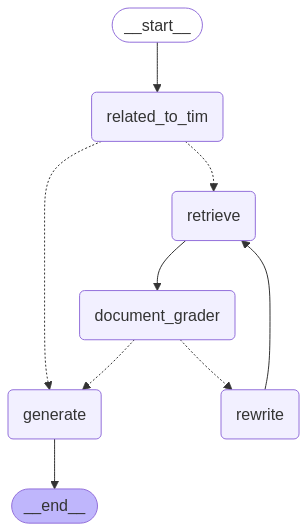

In [ ]:
from IPython.display import Image, display
from langchain_core.runnables.graph import MermaidDrawMethod

display(Image(graph.get_graph().draw_mermaid_png(
    draw_method=MermaidDrawMethod.API,
)))